In [3]:
# Load Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from functools import reduce
from plotnine import * 
import statsmodels.formula.api as smf

In [4]:
election_2018 = pd.read_csv("/Users/hrishikroy/Documents/final_project/commune_results_election_2018.csv",
    encoding="latin1")

election_2022 = pd.read_csv("/Users/hrishikroy/Documents/final_project/commune_results_election_2022.csv",
    encoding="latin1")

In [5]:
election_2022.rename(columns={"CIRC-REG": "CIRCOSCRIZIONE"}, inplace=True) 

In [6]:
election_2022.rename(columns={"centre_right_coalition_perc": "centre_right_coalition_perc_22"}, inplace=True) 
election_2018.rename(columns={"centre_right_coalition_perc": "centre_right_coalition_perc_18"}, inplace=True) 

In [7]:
election_2022.rename(columns={"centre_left_coalition_perc": "centre_left_coalition_perc_22"}, inplace=True) 
election_2018.rename(columns={"centre_left_coalition_perc": "centre_left_coalition_perc_18"}, inplace=True) 

In [8]:
merged_elections = election_2018.merge(
    election_2022,
    on = ["CIRCOSCRIZIONE", "COMUNE"],
    how = "left")

In [9]:
merged_elections["centre_left_change_22_18"] = (merged_elections["centre_left_coalition_perc_22"] 
    - merged_elections["centre_left_coalition_perc_18"])

merged_elections["centre_right_change_22_18"] = (merged_elections["centre_right_coalition_perc_22"] 
    - merged_elections["centre_right_coalition_perc_18"])

In [10]:
cas_df = pd.read_csv('/Users/hrishikroy/Documents/final_project/cas_data.csv') 

In [11]:
cas_df["Data rilevazione...2"] = pd.to_datetime(cas_df["Data rilevazione...2"])

cas_by_year = {year: cas_df[cas_df["Data rilevazione...2"] == pd.to_datetime(f"{year}-12-31")]
    for year in range(2018, 2024)}

cas_data_2018 = cas_by_year[2018]
cas_data_2019 = cas_by_year[2019]
cas_data_2020 = cas_by_year[2020]
cas_data_2021 = cas_by_year[2021]
cas_data_2022 = cas_by_year[2022]
cas_data_2023 = cas_by_year[2023]

In [12]:
cas_comune_2018 = (cas_data_2018
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2018=("Presenze giornaliere", "sum"),
        total_centers_CAS_2018=("id_centro", "nunique"))) 

cas_comune_2018["refugees_per_1000_inhabitants_2018"] = (
    cas_comune_2018["total_refugees_CAS_2018"] /
    cas_comune_2018["inhabitants_comune"] * 1000) 

cas_comune_2019 = (cas_data_2019
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2019=("Presenze giornaliere", "sum"),
        total_centers_CAS_2019=("id_centro", "nunique"))) 

cas_comune_2019["refugees_per_1000_inhabitants_2019"] = (
    cas_comune_2019["total_refugees_CAS_2019"] /
    cas_comune_2019["inhabitants_comune"] * 1000)


cas_comune_2020 = (cas_data_2020
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2020=("Presenze giornaliere", "sum"),
        total_centers_CAS_2020=("id_centro", "nunique"))) 

cas_comune_2020["refugees_per_1000_inhabitants_2020"] = (
    cas_comune_2020["total_refugees_CAS_2020"] /
    cas_comune_2020["inhabitants_comune"] * 1000)


cas_comune_2021 = (cas_data_2021
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2021=("Presenze giornaliere", "sum"),
        total_centers_CAS_2021=("id_centro", "nunique"))) 

cas_comune_2021["refugees_per_1000_inhabitants_2021"] = (
    cas_comune_2021["total_refugees_CAS_2021"] /
    cas_comune_2021["inhabitants_comune"] * 1000)


cas_comune_2022 = (cas_data_2022
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2022=("Presenze giornaliere", "sum"),
        total_centers_CAS_2022=("id_centro", "nunique"))) 

cas_comune_2022["refugees_per_1000_inhabitants_2022"] = (
    cas_comune_2022["total_refugees_CAS_2022"] /
    cas_comune_2022["inhabitants_comune"] * 1000)


cas_comune_2023 = (cas_data_2023
    .groupby(["comune_id", "Comune"], as_index=False)
    .agg(
        inhabitants_comune=("Abitanti comune", "first"),
        total_refugees_CAS_2023=("Presenze giornaliere", "sum"),
        total_centers_CAS_2023=("id_centro", "nunique"))) 

cas_comune_2023["refugees_per_1000_inhabitants_2023"] = (
    cas_comune_2023["total_refugees_CAS_2023"] /
    cas_comune_2023["inhabitants_comune"] * 1000)

In [13]:
cas_comune_2018.rename(columns={"Comune": "COMUNE"}, inplace=True)
cas_comune_2019.rename(columns={"Comune": "COMUNE"}, inplace=True) 
cas_comune_2020.rename(columns={"Comune": "COMUNE"}, inplace=True) 
cas_comune_2021.rename(columns={"Comune": "COMUNE"}, inplace=True) 
cas_comune_2022.rename(columns={"Comune": "COMUNE"}, inplace=True)

In [14]:
cas_2018_2019 = cas_comune_2018.merge(
    cas_comune_2019,
    on=["COMUNE", "comune_id"],
    how="left",
    suffixes=("_2018", "_2019"))

In [15]:
cas_2018_2020 = cas_2018_2019.merge(
    cas_comune_2020,
    on=["COMUNE", "comune_id"],
    how="left",
    suffixes=("", "_2020"))

In [16]:
cas_2018_2021 = cas_2018_2020.merge(
    cas_comune_2021,
    on=["COMUNE", "comune_id"],
    how="left",
    suffixes=("", "_2021"))

In [17]:
cas_2018_2022 = cas_2018_2021.merge(
    cas_comune_2022,
    on=["COMUNE", "comune_id"],
    how="left",
    suffixes=("", "_2022"))

In [18]:
rate_cols = ["refugees_per_1000_inhabitants_2018",
    "refugees_per_1000_inhabitants_2019",
    "refugees_per_1000_inhabitants_2020",
    "refugees_per_1000_inhabitants_2021",
    "refugees_per_1000_inhabitants_2022"]

cas_2018_2022["refugees_per_1000_inhabitants_mean"] = (
    cas_2018_2022[rate_cols].mean(axis=1))

In [19]:
reg_data = merged_elections.merge(
    cas_2018_2022[
        [
            "comune_id",
            "COMUNE",
            "refugees_per_1000_inhabitants_mean"
        ]
    ],
    on="COMUNE",
    how="left"
)

In [20]:
unemp_2018 = pd.read_csv("/Users/hrishikroy/Documents/final_project/unemp/unemp_data_2018_with_regione.csv") 
unemp_2019 = pd.read_csv("/Users/hrishikroy/Documents/final_project/unemp/unemp_data_2019_with_regione.csv") 
unemp_2021 = pd.read_csv("/Users/hrishikroy/Documents/final_project/unemp/unemp_data_2021_with_regione.csv") 
unemp_2022 = pd.read_csv("/Users/hrishikroy/Documents/final_project/unemp/unemp_data_2022_with_regione.csv") 

In [21]:
unemp_2018_2019 = unemp_2018.merge(
    unemp_2019,
    on=["comune", "Regione"],
    how="left",
    suffixes=("_2018", "_2019"))

In [22]:
keys = ["comune", "Regione"]

unemp_2021_renamed = unemp_2021.rename(
    columns={col: f"{col}_2021" for col in unemp_2021.columns if col not in keys})

unemp_2018_2021 = unemp_2018_2019.merge(
    unemp_2021_renamed,
    on=keys,
    how="left")

In [23]:
unemp_2022_renamed = unemp_2022.rename(
    columns={col: f"{col}_2022" for col in unemp_2022.columns if col not in keys})

unemp_2018_2022 = unemp_2018_2021.merge(
    unemp_2022_renamed,
    on=keys,
    how="left")

In [24]:
rate_emp = ["employment_rate_2018",
    "employment_rate_2019",
    "employment_rate_2021",
    "employment_rate_2022"] 

unemp_2018_2022["employment_rate_mean"] = (
    unemp_2018_2022[rate_emp].mean(axis=1))

In [25]:
unemp_2018_2022.rename(columns={"comune": "COMUNE"}, inplace=True)

In [26]:
reg_data["COMUNE_upper"] = (
    reg_data["COMUNE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

unemp_2018_2022["COMUNE_upper"] = (
    unemp_2018_2022["COMUNE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [27]:
reg_data_2 = reg_data.merge(
    unemp_2018_2022[["COMUNE_upper", "employment_rate_mean"]],
    on="COMUNE_upper",
    how="left") 

In [170]:
reg_model_data = reg_data_2[["centre_left_change_22_18",
        "refugees_per_1000_inhabitants_mean",
        "employment_rate_mean", "centre_left_coalition_perc_18"]].dropna()

model_controls = smf.ols(
    "centre_left_change_22_18 ~ refugees_per_1000_inhabitants_mean + employment_rate_mean + centre_left_coalition_perc_18",
    data=reg_model_data
).fit()

print(model_controls.summary())

                               OLS Regression Results                               
Dep. Variable:     centre_left_change_22_18   R-squared:                       0.069
Model:                                  OLS   Adj. R-squared:                  0.068
Method:                       Least Squares   F-statistic:                     71.47
Date:                      Sun, 31 May 2026   Prob (F-statistic):           1.41e-44
Time:                              14:59:34   Log-Likelihood:                -7931.2
No. Observations:                      2879   AIC:                         1.587e+04
Df Residuals:                          2875   BIC:                         1.589e+04
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

,centre_left_change_22_18,refugees_per_1000_inhabitants_mean,employment_rate_mean,centre_left_coalition_perc_18
0,-1.003363,1.365644,69.1950,38.186263
1,-5.413968,1.365644,69.1950,38.186263
2,12.199443,1.365644,69.1950,24.983457
3,7.788838,1.365644,69.1950,24.983457
4,6.008897,1.365644,69.1950,31.174003
...,...,...,...,...
7674,8.695839,8.271017,55.0150,13.125621
7695,8.485238,0.324168,61.6950,13.442453
7697,8.125583,2.283193,60.8875,16.098707
7706,8.738880,6.473724,53.4325,15.055031


In [172]:
model_vars = [
    "centre_left_change_22_18",
    "refugees_per_1000_inhabitants_mean",
    "employment_rate_mean"]

print(reg_data_2[model_vars].isna().sum())
print(reg_data_2[model_vars].dropna().shape)

centre_left_change_22_18               446
refugees_per_1000_inhabitants_mean    5127
employment_rate_mean                   266
dtype: int64
(2879, 3)


In [174]:
print(reg_data_2["employment_rate_mean"].notna().sum())

7822


In [32]:
reg_model_data

,centre_left_change_22_18,refugees_per_1000_inhabitants_mean,employment_rate_mean,centre_left_coalition_perc_18
0,-1.003363,1.365644,69.1950,38.186263
1,-5.413968,1.365644,69.1950,38.186263
2,12.199443,1.365644,69.1950,24.983457
3,7.788838,1.365644,69.1950,24.983457
4,6.008897,1.365644,69.1950,31.174003
...,...,...,...,...
7674,8.695839,8.271017,55.0150,13.125621
7695,8.485238,0.324168,61.6950,13.442453
7697,8.125583,2.283193,60.8875,16.098707
7706,8.738880,6.473724,53.4325,15.055031


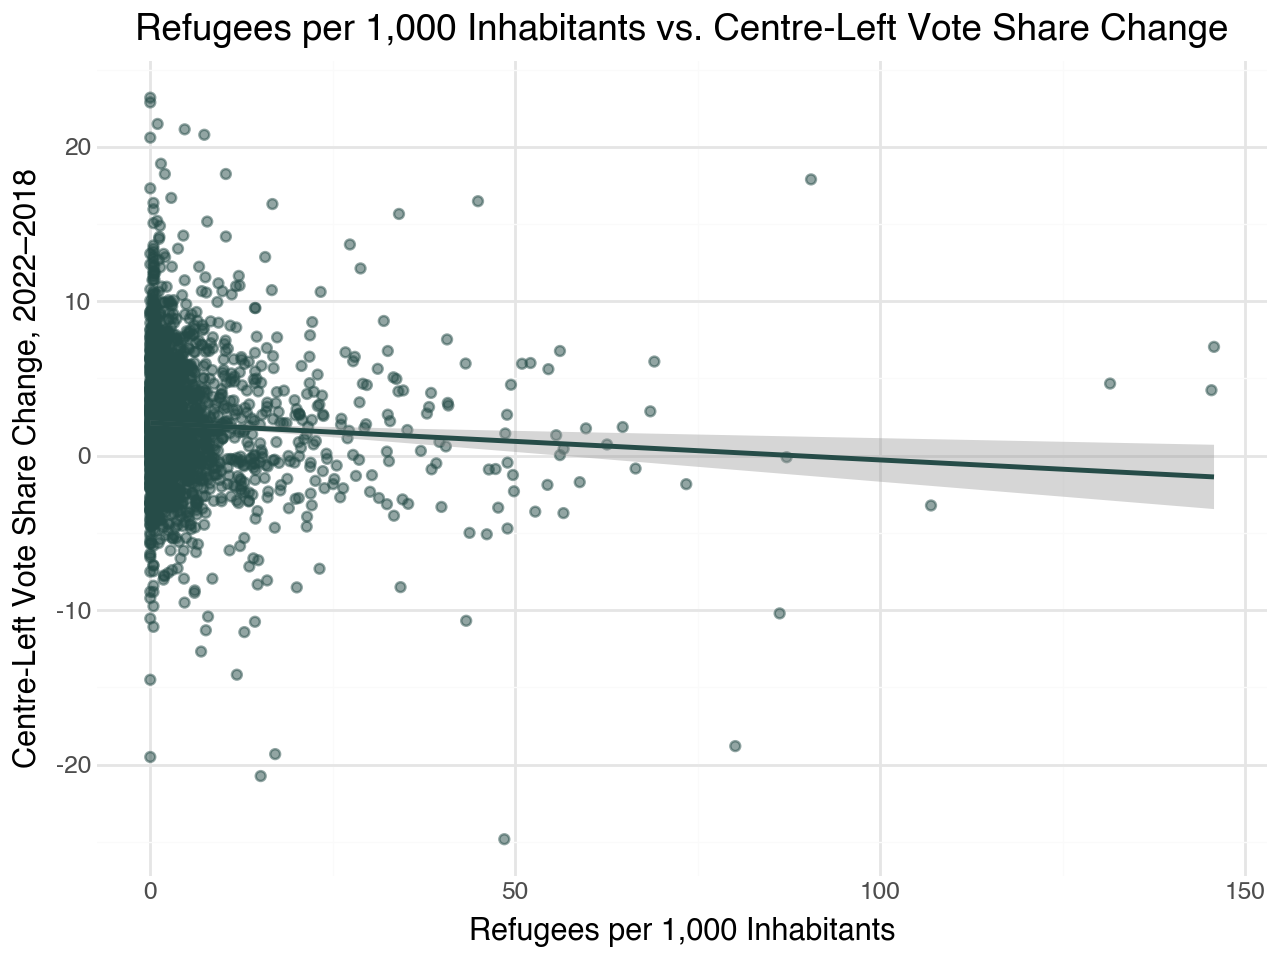

In [41]:
reg_model_data = reg_data_2[
    ["centre_left_change_22_18",
        "refugees_per_1000_inhabitants_mean",
        "employment_rate_mean",
        "centre_left_coalition_perc_18"]].dropna()

plot = (ggplot(reg_model_data,
        aes(x="refugees_per_1000_inhabitants_mean",
            y="centre_left_change_22_18"))
    + geom_point(alpha=0.5, color="#264C48")
    + geom_smooth(method="lm", se=True, color="#264C48")
    + labs(title="Refugees per 1,000 Inhabitants vs. Centre-Left Vote Share Change",
        x="Refugees per 1,000 Inhabitants",
        y="Centre-Left Vote Share Change, 2022–2018")
    + theme_minimal())

plot

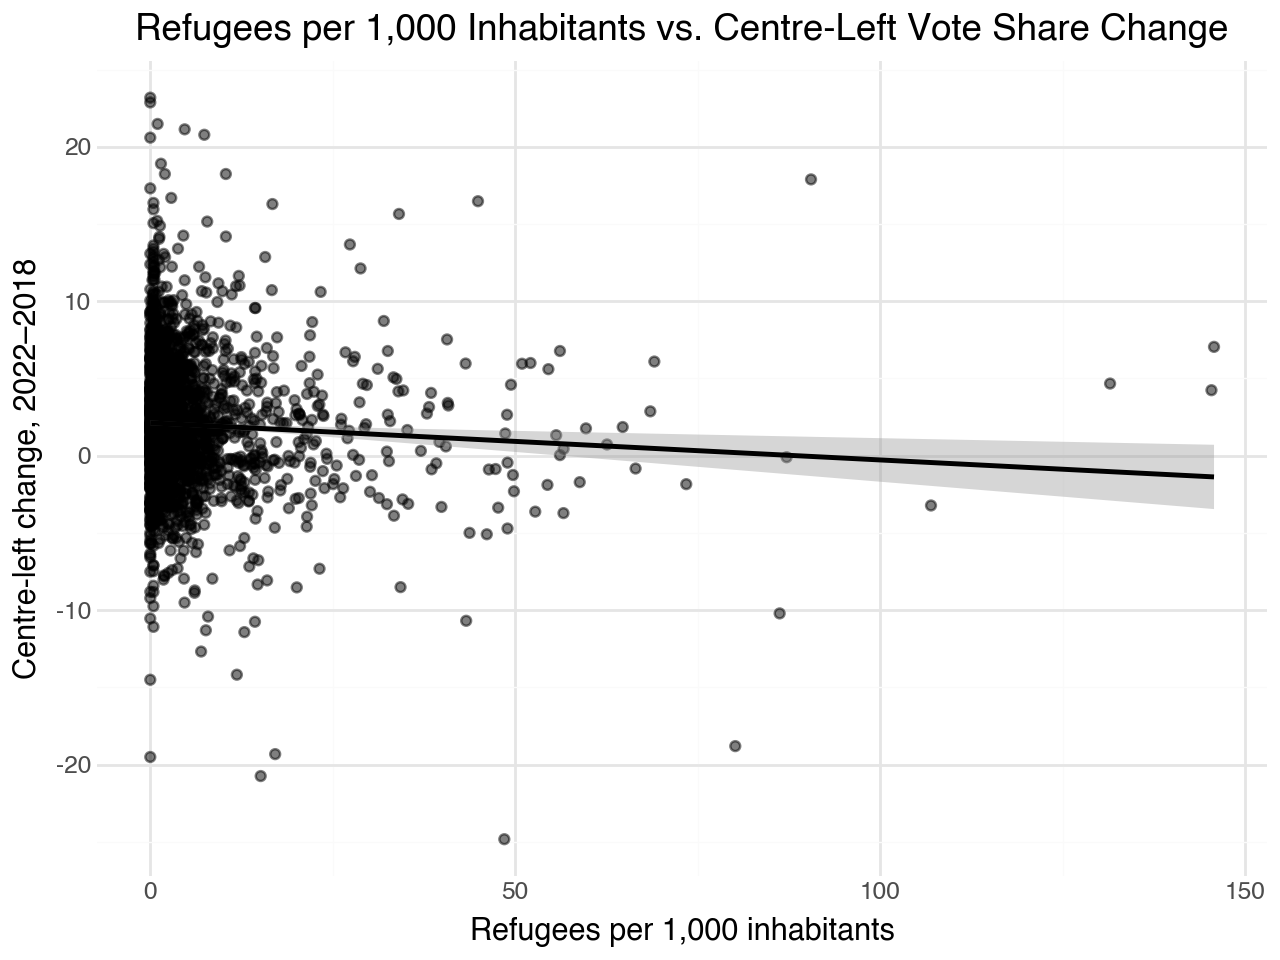

In [30]:
plot